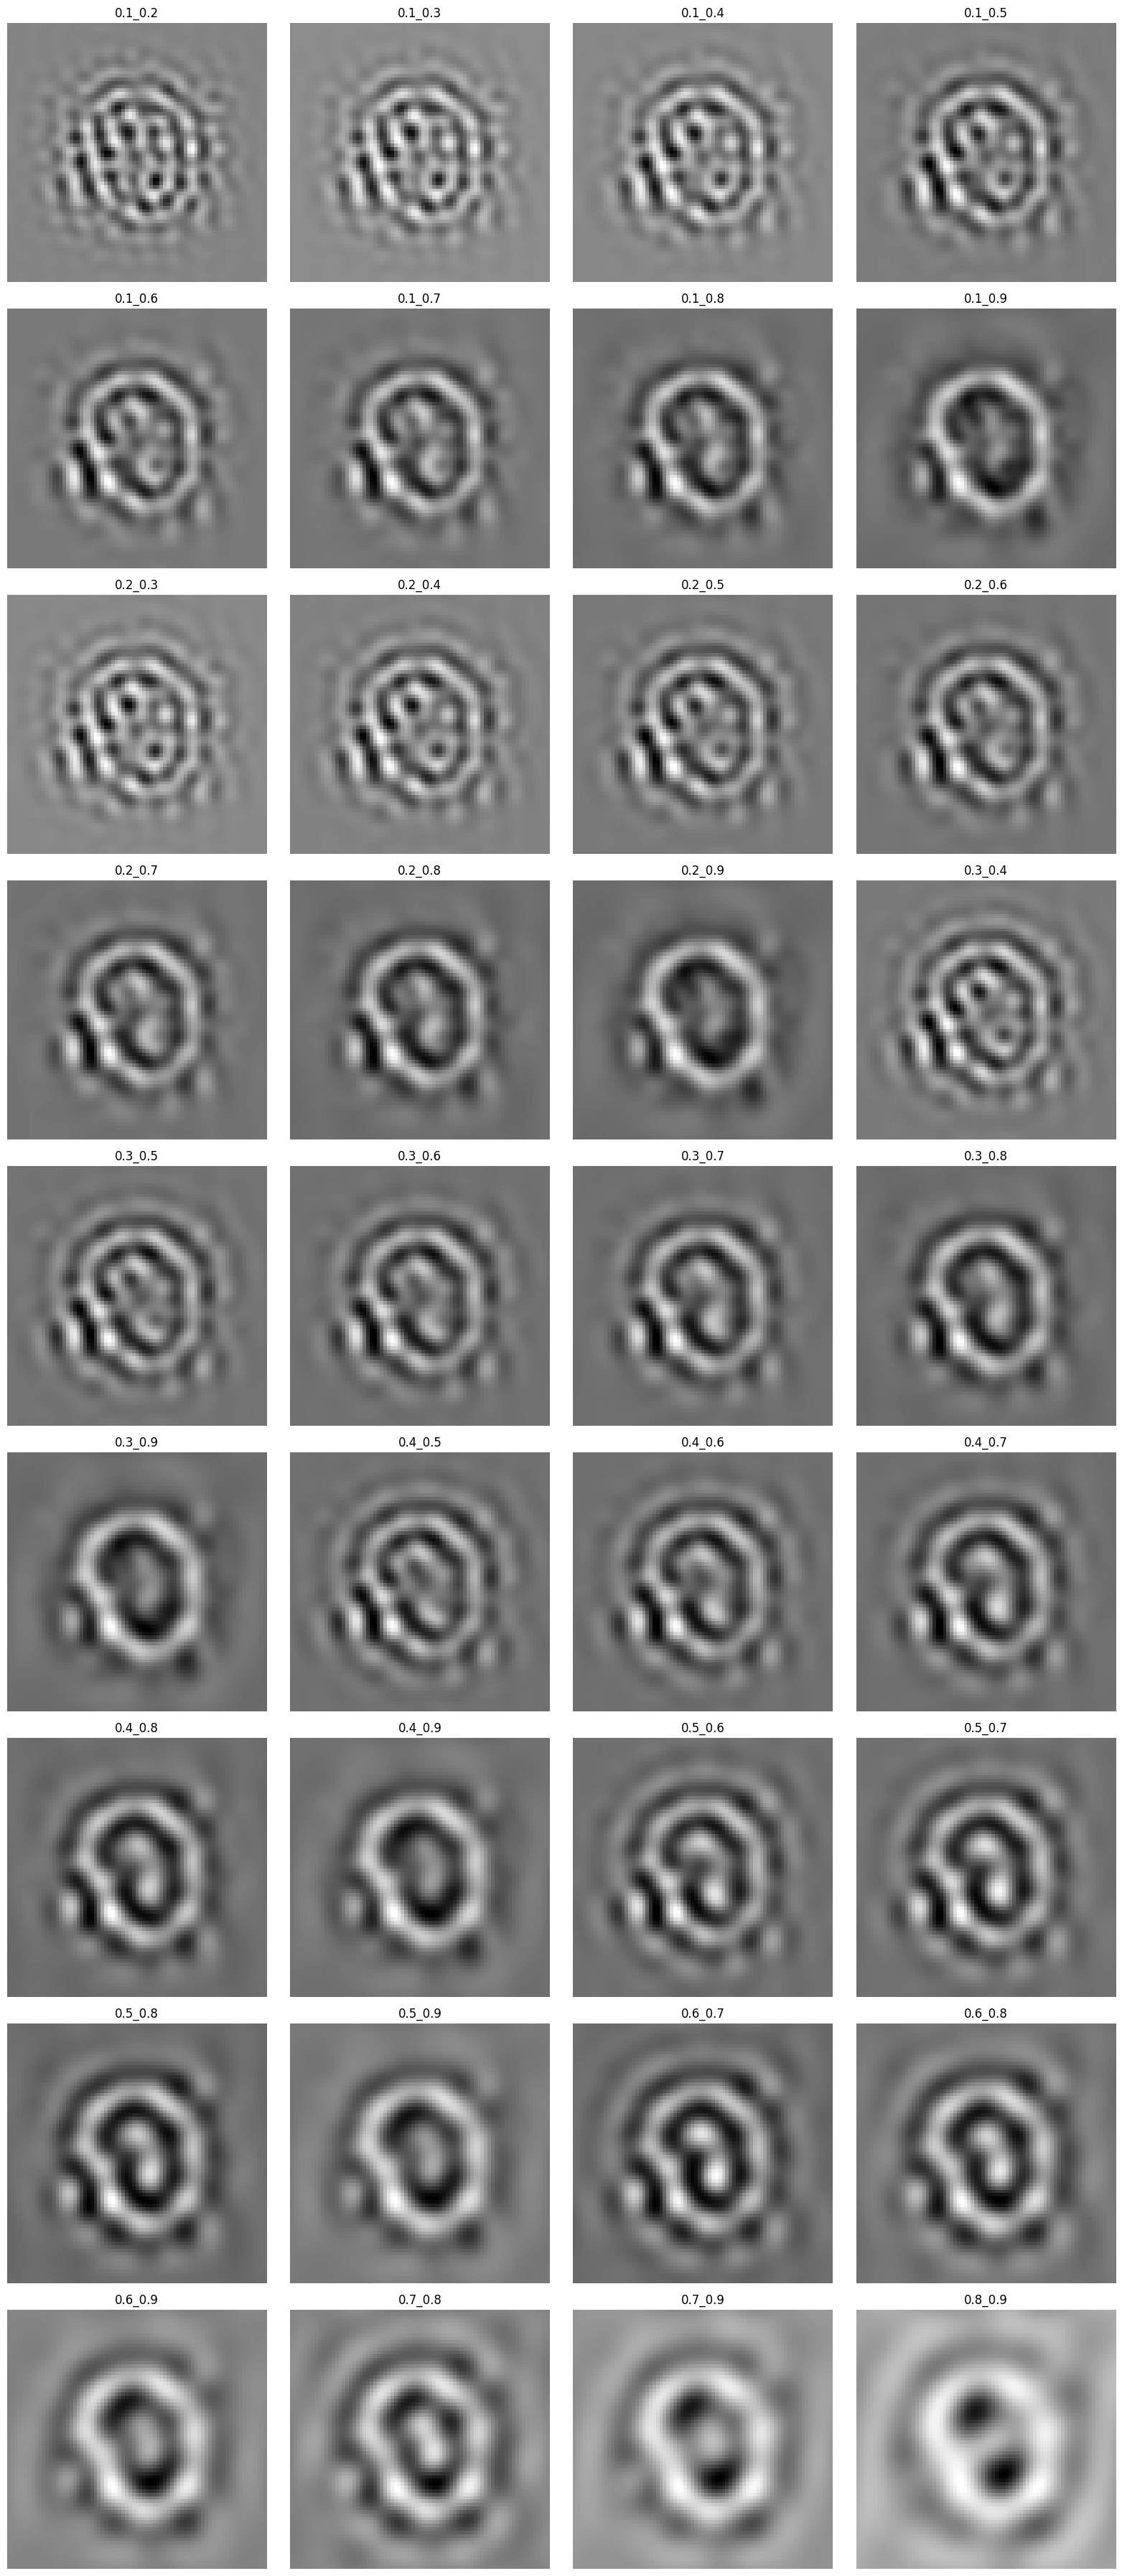

In [9]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

root_dir = "/Users/jacob_kitz/frequency_csvs/little_vessel"

images = []
labels = []

for cutoff in sorted(os.listdir(root_dir)):
    cutoff_path = os.path.join(root_dir, cutoff)

    if not os.path.isdir(cutoff_path):
        continue

    img_path = os.path.join(cutoff_path, "1024_DFOV_300", "image_bp.nii.gz")

    if os.path.exists(img_path):
        img = nib.load(img_path).get_fdata()

        images.append(img)
        labels.append(cutoff)

# plotting
n = len(images)
cols = 4
rows = int(np.ceil(n / cols))

plt.figure(figsize=(4 * cols, 4 * rows))

for i, (img, label) in enumerate(zip(images, labels)):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()